# K-NEAREST NEIGHBORS (KNN) - HỒI QUY VÀ PHÂN LOẠI

**Sinh viên thực hiện:** Hoàng Ngọc Long  
**MSV:** 22001608  

---

## MỤC LỤC

### PHẦN 1: BÀI TOÁN HỒI QUY VỚI KNN
1. Load và Khám phá Dữ liệu
2. Phân tích và Trực quan hóa Dữ liệu
   - 2.1. Chuẩn hóa dữ liệu
   - 2.2. Giảm chiều với PCA
   - 2.3. Trực quan hóa với PCA
3. Hồi quy KNN
   - 3.1. KNN Hardcode (Tự code từ đầu)
   - 3.2. KNN với Thư viện (sklearn)
   - 3.3. So sánh với các tỷ lệ train/validation khác nhau
   - 3.4. Phân tích phần dư
   - 3.5. Chuyển sang bài toán phân loại

### PHẦN 2: BÀI TOÁN PHÂN LOẠI VỚI KNN
1. Chuẩn bị Dữ liệu Phân loại
2. Phân loại KNN
   - 2.1. KNN Classifier Hardcode
   - 2.2. KNN Classifier với Sklearn
   - 2.3. So sánh kết quả
   - 2.4. Đánh giá với Confusion Matrix
---

# PHẦN 1: BÀI TOÁN HỒI QUY VỚI KNN

---

## 1. IMPORT THƯ VIỆN VÀ LOAD DỮ LIỆU

In [43]:
# Import các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Thư viện cho giảm chiều
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE

# Thư viện cho chuẩn hóa
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Thư viện cho phân cụm
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Thư viện cho phân tách dữ liệu
from sklearn.model_selection import train_test_split, cross_val_score

# Thư viện cho KNN
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# Thư viện cho đánh giá
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Import thư viện thành công")

Import thư viện thành công


### 1.1. Load Dữ liệu

In [27]:
# Load dữ liệu đã được tiền xử lý
df_train_features = pd.read_csv('preprocessed_train_features-1.csv')
df_train_target = pd.read_csv('preprocessed_train_target-1.csv')
df_test_features = pd.read_csv('preprocessed_test_features-1.csv')

# Kết hợp features và target cho training set
df_train = df_train_features.copy()
df_train['target'] = df_train_target.values

print("="*80)
print("THÔNG TIN DỮ LIỆU HUẤN LUYỆN")
print("="*80)
print(f"\nKích thước dữ liệu:")
print(f"   - Training features: {df_train_features.shape}")
print(f"   - Training target: {df_train_target.shape}")
print(f"   - Test features: {df_test_features.shape}")

print(f"\nThống kê cơ bản về target (SalePrice_log1p):")
print(df_train_target.describe())

print(f"\n5 mẫu đầu tiên của features:")
print(df_train_features.head())

print(f"\n5 giá trị target đầu tiên:")
print(df_train_target.head())

THÔNG TIN DỮ LIỆU HUẤN LUYỆN

Kích thước dữ liệu:
   - Training features: (1455, 204)
   - Training target: (1455, 1)
   - Test features: (1459, 204)

Thống kê cơ bản về target (SalePrice_log1p):
       SalePrice_log1p
count      1455.000000
mean         12.024218
std           0.399526
min          10.460271
25%          11.774913
50%          12.001512
75%          12.273736
max          13.534474

5 mẫu đầu tiên của features:
   GrLivArea  TotalBsmtSF   LotArea  GarageArea  PoolArea  LotFrontage  \
0   0.539647    -0.472562 -0.126770    0.372329 -0.064336    -0.077391   
1  -0.380341     0.507161  0.122140   -0.049239 -0.064336     0.561080   
2   0.671348    -0.318123  0.431545    0.659761 -0.064336     0.061193   
3   0.552019    -0.713873  0.111953    0.822640 -0.064336    -0.322999   
4   1.300044     0.224827  0.894067    1.752005 -0.064336     0.711356   

   2ndFlrSF  LowQualFinSF  BsmtUnfSF  1stFlrSF  TotRmsAbvGrd  Fireplaces  \
0  1.180741     -0.133836  -0.338862 -0.805538

## 2. PHÂN TÍCH VÀ TRỰC QUAN HÓA DỮ LIỆU

### 2.1. Chuẩn hóa dữ liệu

In [28]:
# Chuẩn hóa dữ liệu bằng StandardScaler
X = df_train_features.values
y = df_train_target.values.ravel()
X_test = df_test_features.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("="*80)
print("CHUẨN HÓA DỮ LIỆU")
print("="*80)
print(f"\nĐã chuẩn hóa dữ liệu với StandardScaler")
print(f"   - Shape của X_scaled: {X_scaled.shape}")
print(f"   - Mean: {X_scaled.mean():.6f} (xấp xỉ 0)")
print(f"   - Std: {X_scaled.std():.6f} (xấp xỉ 1)")

# Phân tích thống kê
print(f"\nThống kê dữ liệu gốc:")
print(f"   - Min: {X.min():.2f}")
print(f"   - Max: {X.max():.2f}")
print(f"   - Mean: {X.mean():.2f}")
print(f"   - Std: {X.std():.2f}")

print(f"\nThống kê dữ liệu sau chuẩn hóa:")
print(f"   - Min: {X_scaled.min():.2f}")
print(f"   - Max: {X_scaled.max():.2f}")
print(f"   - Mean: {X_scaled.mean():.6f}")
print(f"   - Std: {X_scaled.std():.2f}")

CHUẨN HÓA DỮ LIỆU

Đã chuẩn hóa dữ liệu với StandardScaler
   - Shape của X_scaled: (1455, 204)
   - Mean: -0.000000 (xấp xỉ 0)
   - Std: 1.000000 (xấp xỉ 1)

Thống kê dữ liệu gốc:
   - Min: -8.74
   - Max: 15500.00
   - Mean: 13.80
   - Std: 147.16

Thống kê dữ liệu sau chuẩn hóa:
   - Min: -17.03
   - Max: 38.13
   - Mean: -0.000000
   - Std: 1.00


### 2.2. Giảm chiều với PCA (Principal Component Analysis)

GIẢM CHIỀU VỚI PCA

 Kết quả PCA:
   - Số chiều ban đầu: 204
   - Số components được tính: 50
   - Explained variance của PC1: 0.0827
   - Explained variance của PC2: 0.0340
   - Tổng explained variance (top 10 PCs): 0.2706
   - Số components để giữ 95% variance: 1
   - Số components = 1/3 số chiều gốc: 50


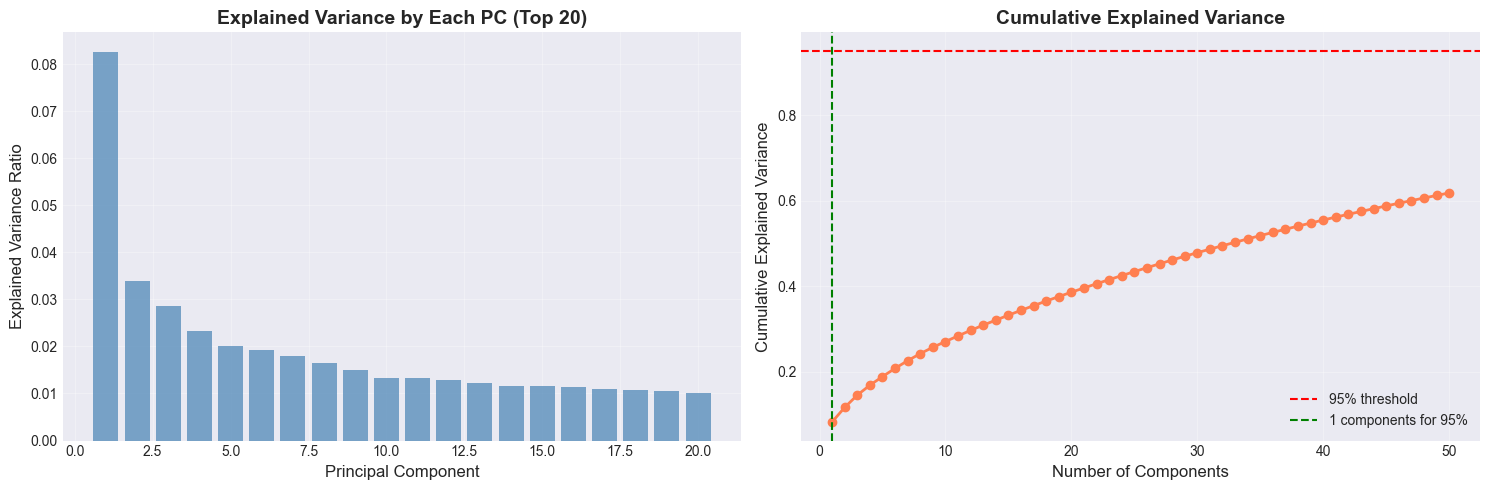


 Tạo dữ liệu PCA giảm chiều:
   - Shape gốc: (1455, 204)
   - Shape sau PCA (1/3): (1455, 50)
   - Variance giữ lại: 0.6180


In [29]:
# Áp dụng PCA
n_components_pca = min(50, X_scaled.shape[1])  # Lấy tối đa 50 components
pca = PCA(n_components=n_components_pca)
X_pca = pca.fit_transform(X_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Tính explained variance ratio
explained_var_ratio = pca.explained_variance_ratio_
cumulative_var_ratio = np.cumsum(explained_var_ratio)

# Tìm số components để giữ 95% variance
n_comp_95 = np.argmax(cumulative_var_ratio >= 0.95) + 1
# Tìm số components để giữ 1/3 số chiều (nhưng không vượt quá số components đã tính)
n_comp_third = min(X_scaled.shape[1] // 3, n_components_pca)

print("="*80)
print("GIẢM CHIỀU VỚI PCA")
print("="*80)
print(f"\n Kết quả PCA:")
print(f"   - Số chiều ban đầu: {X_scaled.shape[1]}")
print(f"   - Số components được tính: {n_components_pca}")
print(f"   - Explained variance của PC1: {explained_var_ratio[0]:.4f}")
print(f"   - Explained variance của PC2: {explained_var_ratio[1]:.4f}")
print(f"   - Tổng explained variance (top 10 PCs): {cumulative_var_ratio[9]:.4f}")
print(f"   - Số components để giữ 95% variance: {n_comp_95}")
print(f"   - Số components = 1/3 số chiều gốc: {n_comp_third}")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Individual explained variance
axes[0].bar(range(1, min(21, len(explained_var_ratio)+1)), 
            explained_var_ratio[:20], 
            alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Explained Variance by Each PC (Top 20)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_var_ratio)+1), 
             cumulative_var_ratio, 
             marker='o', linestyle='-', color='coral', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].axvline(x=n_comp_95, color='g', linestyle='--', 
                label=f'{n_comp_95} components for 95%')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tạo dữ liệu PCA với số chiều giảm xuống 1/3
X_pca_reduced = X_pca[:, :n_comp_third]
X_test_pca_reduced = X_test_pca[:, :n_comp_third]

print(f"\n Tạo dữ liệu PCA giảm chiều:")
print(f"   - Shape gốc: {X_scaled.shape}")
print(f"   - Shape sau PCA (1/3): {X_pca_reduced.shape}")
print(f"   - Variance giữ lại: {cumulative_var_ratio[min(n_comp_third-1, len(cumulative_var_ratio)-1)]:.4f}")

### 2.3. Trực quan hóa dữ liệu với các thành phần chính

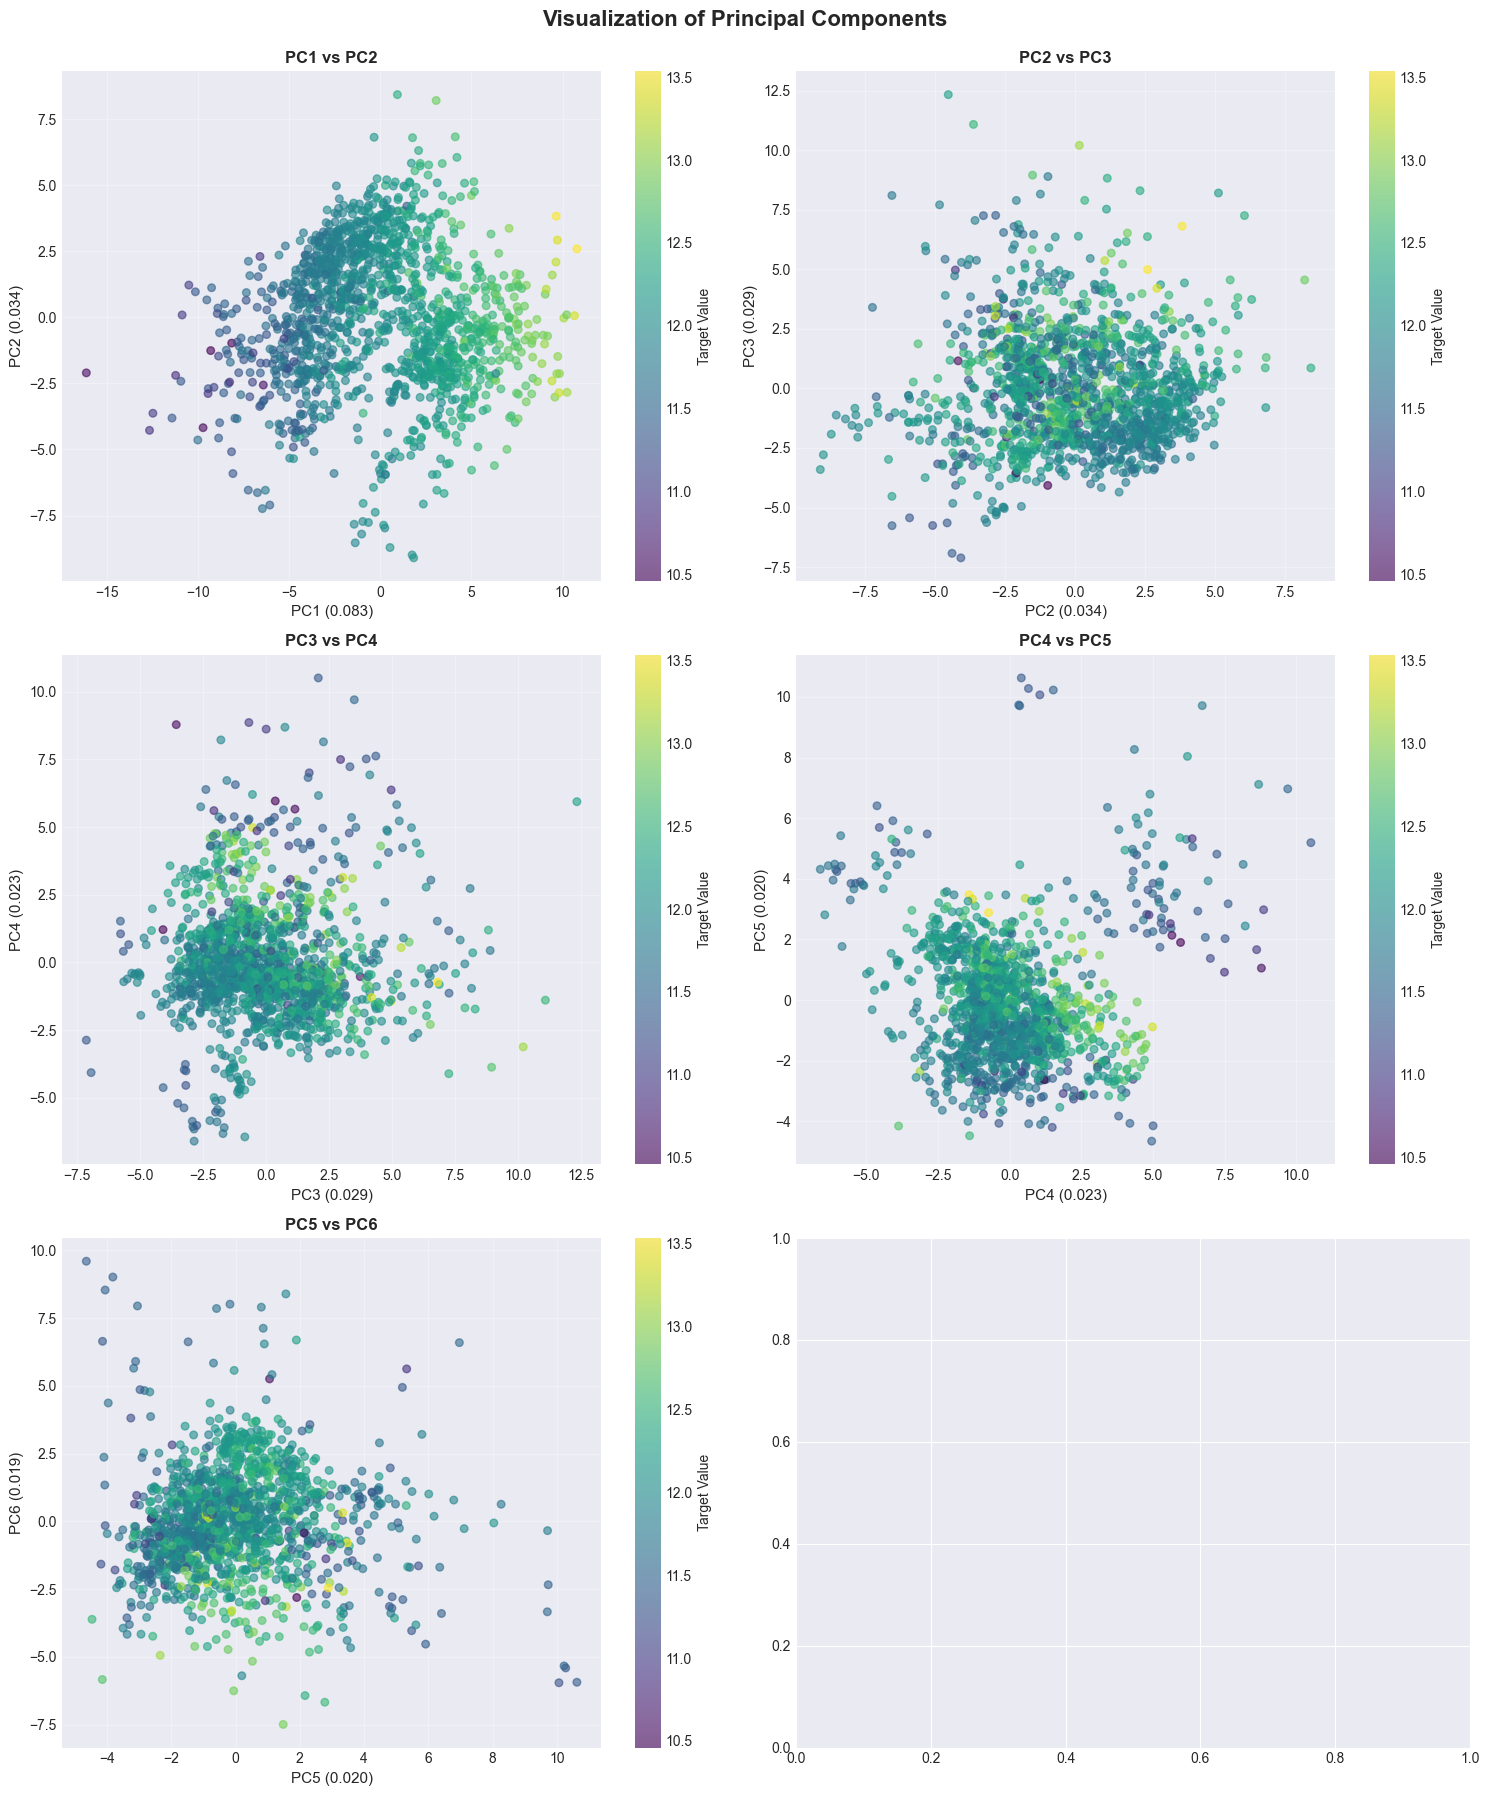

In [44]:
# Trực quan hóa 6 thành phần chính đầu tiên
n_comp_visualize = 6
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.ravel()

for i in range(min(n_comp_visualize-1, len(axes))):
    # Vẽ scatter plot cho PC(i) vs PC(i+1)
    scatter = axes[i].scatter(X_pca[:, i], X_pca[:, i+1], 
                             c=y, cmap='viridis', alpha=0.6, s=30)
    axes[i].set_xlabel(f'PC{i+1} ({explained_var_ratio[i]:.3f})', fontsize=11)
    axes[i].set_ylabel(f'PC{i+2} ({explained_var_ratio[i+1]:.3f})', fontsize=11)
    axes[i].set_title(f'PC{i+1} vs PC{i+2}', fontsize=12, fontweight='bold')
    axes[i].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[i], label='Target Value')

plt.suptitle('Visualization of Principal Components', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 3. HỒI QUY KNN

---

### 3.1. KNN HARDCODE

In [31]:
class KNNRegressorHardcode:
    """
    K-Nearest Neighbors Regressor - Implementation from scratch
    
    Parameters:
    -----------
    k : int
        Number of nearest neighbors to use
    distance_metric : str
        Distance metric to use ('euclidean' or 'manhattan')
    """
    
    def __init__(self, k=5, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        """
        Lưu trữ dữ liệu training
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        y : array-like, shape (n_samples,)
            Target values
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def _calculate_distance(self, x1, x2):
        """
        Tính khoảng cách giữa 2 điểm
        
        Parameters:
        -----------
        x1, x2 : array-like
            Two data points
            
        Returns:
        --------
        distance : float
        """
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("Unknown distance metric")
    
    def _predict_single(self, x):
        """
        Dự đoán cho một mẫu dữ liệu
        
        Parameters:
        -----------
        x : array-like
            Single data point
            
        Returns:
        --------
        prediction : float
        """
        # Tính khoảng cách đến tất cả các điểm training
        distances = []
        for i in range(len(self.X_train)):
            dist = self._calculate_distance(x, self.X_train[i])
            distances.append((dist, self.y_train[i]))
        
        # Sắp xếp theo khoảng cách
        distances.sort(key=lambda x: x[0])
        
        # Lấy k láng giềng gần nhất
        k_nearest = distances[:self.k]
        
        # Tính trung bình target của k láng giềng
        prediction = np.mean([target for _, target in k_nearest])
        
        return prediction
    
    def predict(self, X):
        """
        Dự đoán cho nhiều mẫu dữ liệu
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Test data
            
        Returns:
        --------
        predictions : array, shape (n_samples,)
        """
        X = np.array(X)
        predictions = []
        for x in X:
            predictions.append(self._predict_single(x))
        return np.array(predictions)
    
    def score(self, X, y):
        """
        Tính R² score
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Test data
        y : array-like, shape (n_samples,)
            True target values
            
        Returns:
        --------
        r2_score : float
        """
        y_pred = self.predict(X)
        return r2_score(y, y_pred)

print("="*80)
print(" ĐÃ TẠO CLASS KNNRegressorHardcode")
print("="*80)
print("\nCác phương thức:")
print("  - fit(X, y): Huấn luyện mô hình")
print("  - predict(X): Dự đoán giá trị")
print("  - score(X, y): Tính R² score")
print("  - _calculate_distance(): Tính khoảng cách Euclidean/Manhattan")
print("  - _predict_single(): Dự đoán cho 1 mẫu")

 ĐÃ TẠO CLASS KNNRegressorHardcode

Các phương thức:
  - fit(X, y): Huấn luyện mô hình
  - predict(X): Dự đoán giá trị
  - score(X, y): Tính R² score
  - _calculate_distance(): Tính khoảng cách Euclidean/Manhattan
  - _predict_single(): Dự đoán cho 1 mẫu


#### 3.1.1. Test KNN Hardcode với các tỷ lệ Train/Validation khác nhau

In [32]:
# Test với DỮ LIỆU GỐC
print("="*80)
print("KNN HARDCODE - DỮ LIỆU GỐC (FULL FEATURES)")
print("="*80)

# Các tỷ lệ train:validation
split_ratios = [
    (0.8, '4:1'),   # 80% train, 20% validation
    (0.7, '7:3'),   # 70% train, 30% validation
    (0.6, '6:4')    # 60% train, 40% validation
]

# Thử với các giá trị k khác nhau
k_values = [3, 5, 7, 9]

results_hardcode_full = []

for train_size, ratio_name in split_ratios:
    print(f"\n{'='*60}")
    print(f"TỶ LỆ TRAIN:VALIDATION = {ratio_name}")
    print(f"{'='*60}")
    
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y, train_size=train_size, random_state=42
    )
    
    for k in k_values:
        # Train model
        model = KNNRegressorHardcode(k=k, distance_metric='euclidean')
        model.fit(X_train, y_train)
        
        # Predict - chỉ lấy 100 mẫu đầu để tăng tốc
        y_pred = model.predict(X_val[:100])
        y_val_subset = y_val[:100]
        
        # Calculate metrics
        mse = mean_squared_error(y_val_subset, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_val_subset, y_pred)
        r2 = r2_score(y_val_subset, y_pred)
        
        results_hardcode_full.append({
            'ratio': ratio_name,
            'k': k,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })
        
        print(f"\n  k = {k}:")
        print(f"    RMSE: {rmse:.4f}")
        print(f"    MAE:  {mae:.4f}")
        print(f"    R²:   {r2:.4f}")

# Convert to DataFrame
df_results_hardcode_full = pd.DataFrame(results_hardcode_full)

print(f"\n{'='*80}")
print("TỔNG KẾT KẾT QUẢ - KNN HARDCODE (DỮ LIỆU GỐC)")
print(f"{'='*80}")
print(df_results_hardcode_full.to_string(index=False))

KNN HARDCODE - DỮ LIỆU GỐC (FULL FEATURES)

TỶ LỆ TRAIN:VALIDATION = 4:1

  k = 3:
    RMSE: 0.2103
    MAE:  0.1482
    R²:   0.7156

  k = 3:
    RMSE: 0.2103
    MAE:  0.1482
    R²:   0.7156

  k = 5:
    RMSE: 0.2077
    MAE:  0.1432
    R²:   0.7225

  k = 5:
    RMSE: 0.2077
    MAE:  0.1432
    R²:   0.7225

  k = 7:
    RMSE: 0.2052
    MAE:  0.1367
    R²:   0.7293

  k = 7:
    RMSE: 0.2052
    MAE:  0.1367
    R²:   0.7293

  k = 9:
    RMSE: 0.2058
    MAE:  0.1407
    R²:   0.7278

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 9:
    RMSE: 0.2058
    MAE:  0.1407
    R²:   0.7278

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 3:
    RMSE: 0.2117
    MAE:  0.1498
    R²:   0.7119

  k = 3:
    RMSE: 0.2117
    MAE:  0.1498
    R²:   0.7119

  k = 5:
    RMSE: 0.2072
    MAE:  0.1441
    R²:   0.7239

  k = 5:
    RMSE: 0.2072
    MAE:  0.1441
    R²:   0.7239

  k = 7:
    RMSE: 0.2039
    MAE:  0.1382
    R²:   0.7328

  k = 7:
    RMSE: 0.2039
    MAE:  0.1382
    R²:   0.7328

  k = 9:
   

### 3.2. KNN VỚI THƯ VIỆN SKLEARN

---

#### 3.2.1. Test trên dữ liệu gốc

In [33]:
# Test với DỮ LIỆU GỐC - SKLEARN
print("="*80)
print("KNN SKLEARN - DỮ LIỆU GỐC (FULL FEATURES)")
print("="*80)

results_sklearn_full = []

for train_size, ratio_name in split_ratios:
    print(f"\n{'='*60}")
    print(f"TỶ LỆ TRAIN:VALIDATION = {ratio_name}")
    print(f"{'='*60}")
    
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y, train_size=train_size, random_state=42
    )
    
    for k in k_values:
        # Train model với sklearn
        model_sklearn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
        model_sklearn.fit(X_train, y_train)
        
        # Predict
        y_pred = model_sklearn.predict(X_val)
        
        # Calculate metrics
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        
        results_sklearn_full.append({
            'ratio': ratio_name,
            'k': k,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })
        
        print(f"\n  k = {k}:")
        print(f"    RMSE: {rmse:.4f}")
        print(f"    MAE:  {mae:.4f}")
        print(f"    R²:   {r2:.4f}")

# Convert to DataFrame
df_results_sklearn_full = pd.DataFrame(results_sklearn_full)

print(f"\n{'='*80}")
print("TỔNG KẾT KẾT QUẢ - KNN SKLEARN (DỮ LIỆU GỐC)")
print(f"{'='*80}")
print(df_results_sklearn_full.to_string(index=False))

KNN SKLEARN - DỮ LIỆU GỐC (FULL FEATURES)

TỶ LỆ TRAIN:VALIDATION = 4:1

  k = 3:
    RMSE: 0.2050
    MAE:  0.1428
    R²:   0.7496

  k = 5:
    RMSE: 0.1947
    MAE:  0.1319
    R²:   0.7743

  k = 7:
    RMSE: 0.1891
    MAE:  0.1277
    R²:   0.7870

  k = 9:
    RMSE: 0.1899
    MAE:  0.1300
    R²:   0.7852

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 3:
    RMSE: 0.1949
    MAE:  0.1362
    R²:   0.7476

  k = 5:
    RMSE: 0.1859
    MAE:  0.1295
    R²:   0.7702

  k = 7:
    RMSE: 0.1779
    MAE:  0.1236
    R²:   0.7896

  k = 9:
    RMSE: 0.1775
    MAE:  0.1248
    R²:   0.7905

TỶ LỆ TRAIN:VALIDATION = 6:4

  k = 3:
    RMSE: 0.2036
    MAE:  0.1392
    R²:   0.7411

  k = 5:
    RMSE: 0.1961
    MAE:  0.1356
    R²:   0.7598

  k = 7:
    RMSE: 0.1931
    MAE:  0.1347
    R²:   0.7670

  k = 9:
    RMSE: 0.1895
    MAE:  0.1328
    R²:   0.7756

TỔNG KẾT KẾT QUẢ - KNN SKLEARN (DỮ LIỆU GỐC)
ratio  k      mse     rmse      mae       r2
  4:1  3 0.042043 0.205043 0.142833 0.749639


#### 3.2.2. Test trên dữ liệu giảm chiều (PCA - 1/3 số chiều)

In [34]:
# Test với DỮ LIỆU GIẢM CHIỀU - SKLEARN
print("="*80)
print("KNN SKLEARN - DỮ LIỆU GIẢM CHIỀU (PCA - 1/3 số chiều)")
print("="*80)
print(f"Số chiều gốc: {X_scaled.shape[1]}")
print(f"Số chiều sau PCA: {X_pca_reduced.shape[1]}")

results_sklearn_pca = []

for train_size, ratio_name in split_ratios:
    print(f"\n{'='*60}")
    print(f"TỶ LỆ TRAIN:VALIDATION = {ratio_name}")
    print(f"{'='*60}")
    
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_pca_reduced, y, train_size=train_size, random_state=42
    )
    
    for k in k_values:
        # Train model với sklearn
        model_sklearn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
        model_sklearn.fit(X_train, y_train)
        
        # Predict
        y_pred = model_sklearn.predict(X_val)
        
        # Calculate metrics
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        
        results_sklearn_pca.append({
            'ratio': ratio_name,
            'k': k,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })
        
        print(f"\n  k = {k}:")
        print(f"    RMSE: {rmse:.4f}")
        print(f"    MAE:  {mae:.4f}")
        print(f"    R²:   {r2:.4f}")

# Convert to DataFrame
df_results_sklearn_pca = pd.DataFrame(results_sklearn_pca)

print(f"\n{'='*80}")
print("TỔNG KẾT KẾT QUẢ - KNN SKLEARN (DỮ LIỆU GIẢM CHIỀU)")
print(f"{'='*80}")
print(df_results_sklearn_pca.to_string(index=False))

KNN SKLEARN - DỮ LIỆU GIẢM CHIỀU (PCA - 1/3 số chiều)
Số chiều gốc: 204
Số chiều sau PCA: 50

TỶ LỆ TRAIN:VALIDATION = 4:1

  k = 3:
    RMSE: 0.1898
    MAE:  0.1318
    R²:   0.7856

  k = 5:
    RMSE: 0.1867
    MAE:  0.1271
    R²:   0.7925

  k = 7:
    RMSE: 0.1848
    MAE:  0.1253
    R²:   0.7967

  k = 9:
    RMSE: 0.1825
    MAE:  0.1259
    R²:   0.8016

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 3:
    RMSE: 0.1821
    MAE:  0.1294
    R²:   0.7797

  k = 5:
    RMSE: 0.1789
    MAE:  0.1252
    R²:   0.7872

  k = 7:
    RMSE: 0.1756
    MAE:  0.1234
    R²:   0.7949

  k = 9:
    RMSE: 0.1728
    MAE:  0.1219
    R²:   0.8016

TỶ LỆ TRAIN:VALIDATION = 6:4

  k = 3:
    RMSE: 0.1933
    MAE:  0.1327
    R²:   0.7664

  k = 3:
    RMSE: 0.1933
    MAE:  0.1327
    R²:   0.7664

  k = 5:
    RMSE: 0.1923
    MAE:  0.1320
    R²:   0.7688

  k = 7:
    RMSE: 0.1838
    MAE:  0.1267
    R²:   0.7888

  k = 9:
    RMSE: 0.1827
    MAE:  0.1267
    R²:   0.7914

TỔNG KẾT KẾT QUẢ - KNN 

### 3.3. SO SÁNH KẾT QUẢ

SO SÁNH: DỮ LIỆU GỐC vs DỮ LIỆU GIẢM CHIỀU

 BEST MODEL - DỮ LIỆU GỐC:
   Ratio: 7:3, k=9
   RMSE: 0.1775
   MAE:  0.1248
   R²:   0.7905

 BEST MODEL - DỮ LIỆU GIẢM CHIỀU:
   Ratio: 4:1, k=9
   RMSE: 0.1825
   MAE:  0.1259
   R²:   0.8016


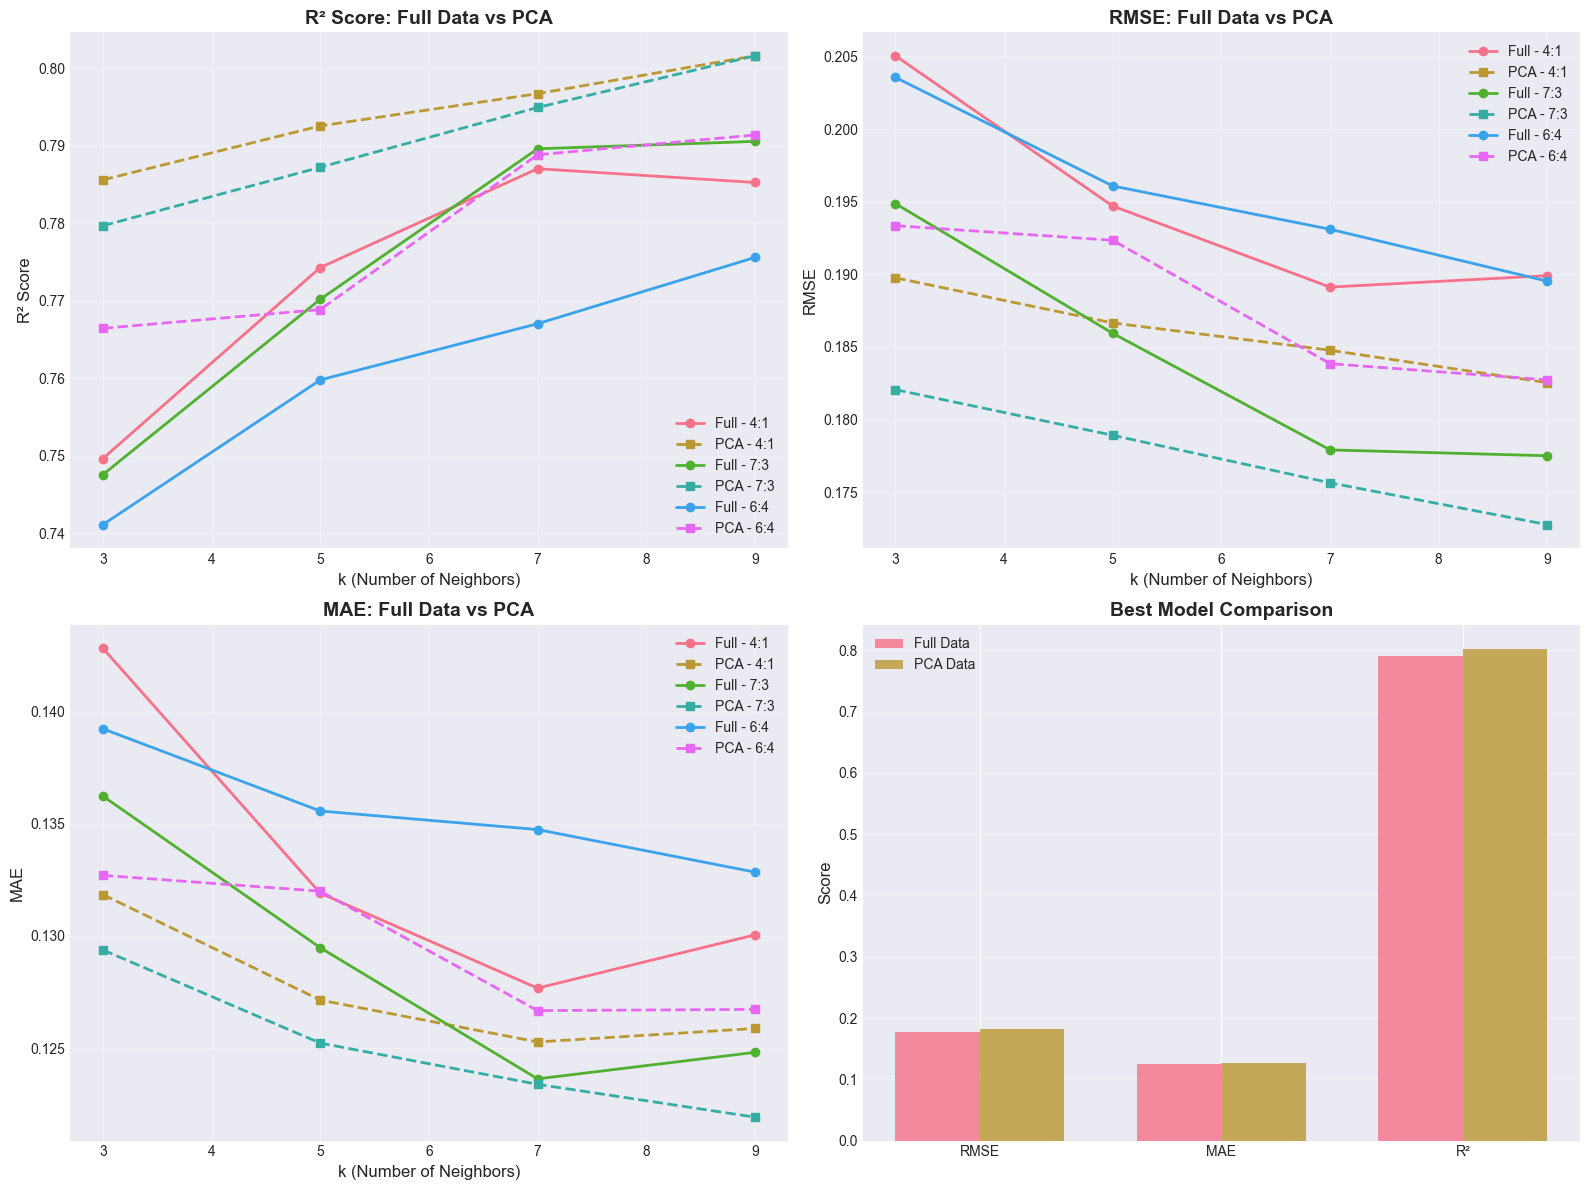

In [35]:
# So sánh hiệu suất giữa dữ liệu gốc và giảm chiều
print("="*80)
print("SO SÁNH: DỮ LIỆU GỐC vs DỮ LIỆU GIẢM CHIỀU")
print("="*80)

# Tìm best model cho mỗi loại
best_full = df_results_sklearn_full.loc[df_results_sklearn_full['r2'].idxmax()]
best_pca = df_results_sklearn_pca.loc[df_results_sklearn_pca['r2'].idxmax()]

print(f"\n BEST MODEL - DỮ LIỆU GỐC:")
print(f"   Ratio: {best_full['ratio']}, k={best_full['k']}")
print(f"   RMSE: {best_full['rmse']:.4f}")
print(f"   MAE:  {best_full['mae']:.4f}")
print(f"   R²:   {best_full['r2']:.4f}")

print(f"\n BEST MODEL - DỮ LIỆU GIẢM CHIỀU:")
print(f"   Ratio: {best_pca['ratio']}, k={best_pca['k']}")
print(f"   RMSE: {best_pca['rmse']:.4f}")
print(f"   MAE:  {best_pca['mae']:.4f}")
print(f"   R²:   {best_pca['r2']:.4f}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: R² Score comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_results_sklearn_full[df_results_sklearn_full['ratio']==ratio_name]
    pca_data = df_results_sklearn_pca[df_results_sklearn_pca['ratio']==ratio_name]
    
    axes[0,0].plot(full_data['k'], full_data['r2'], marker='o', 
                   label=f'Full - {ratio_name}', linewidth=2)
    axes[0,0].plot(pca_data['k'], pca_data['r2'], marker='s', 
                   linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[0,0].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0,0].set_ylabel('R² Score', fontsize=12)
axes[0,0].set_title('R² Score: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Plot 2: RMSE comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_results_sklearn_full[df_results_sklearn_full['ratio']==ratio_name]
    pca_data = df_results_sklearn_pca[df_results_sklearn_pca['ratio']==ratio_name]
    
    axes[0,1].plot(full_data['k'], full_data['rmse'], marker='o', 
                   label=f'Full - {ratio_name}', linewidth=2)
    axes[0,1].plot(pca_data['k'], pca_data['rmse'], marker='s', 
                   linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[0,1].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0,1].set_ylabel('RMSE', fontsize=12)
axes[0,1].set_title('RMSE: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Plot 3: MAE comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_results_sklearn_full[df_results_sklearn_full['ratio']==ratio_name]
    pca_data = df_results_sklearn_pca[df_results_sklearn_pca['ratio']==ratio_name]
    
    axes[1,0].plot(full_data['k'], full_data['mae'], marker='o', 
                   label=f'Full - {ratio_name}', linewidth=2)
    axes[1,0].plot(pca_data['k'], pca_data['mae'], marker='s', 
                   linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[1,0].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[1,0].set_ylabel('MAE', fontsize=12)
axes[1,0].set_title('MAE: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Plot 4: Bar chart best models
categories = ['RMSE', 'MAE', 'R²']
full_values = [best_full['rmse'], best_full['mae'], best_full['r2']]
pca_values = [best_pca['rmse'], best_pca['mae'], best_pca['r2']]

x = np.arange(len(categories))
width = 0.35

axes[1,1].bar(x - width/2, full_values, width, label='Full Data', alpha=0.8)
axes[1,1].bar(x + width/2, pca_values, width, label='PCA Data', alpha=0.8)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(categories)
axes[1,1].set_ylabel('Score', fontsize=12)
axes[1,1].set_title('Best Model Comparison', fontsize=14, fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.4. PHÂN TÍCH PHẦN DƯ (Residuals Analysis)

PHÂN TÍCH PHẦN DƯ

Best Model: k=9, ratio=7:3

Thống kê phần dư:
  Mean: -0.007010 (≈ 0 is good)
  Std:  0.1774
  Min:  -1.2060
  Max:  0.7850


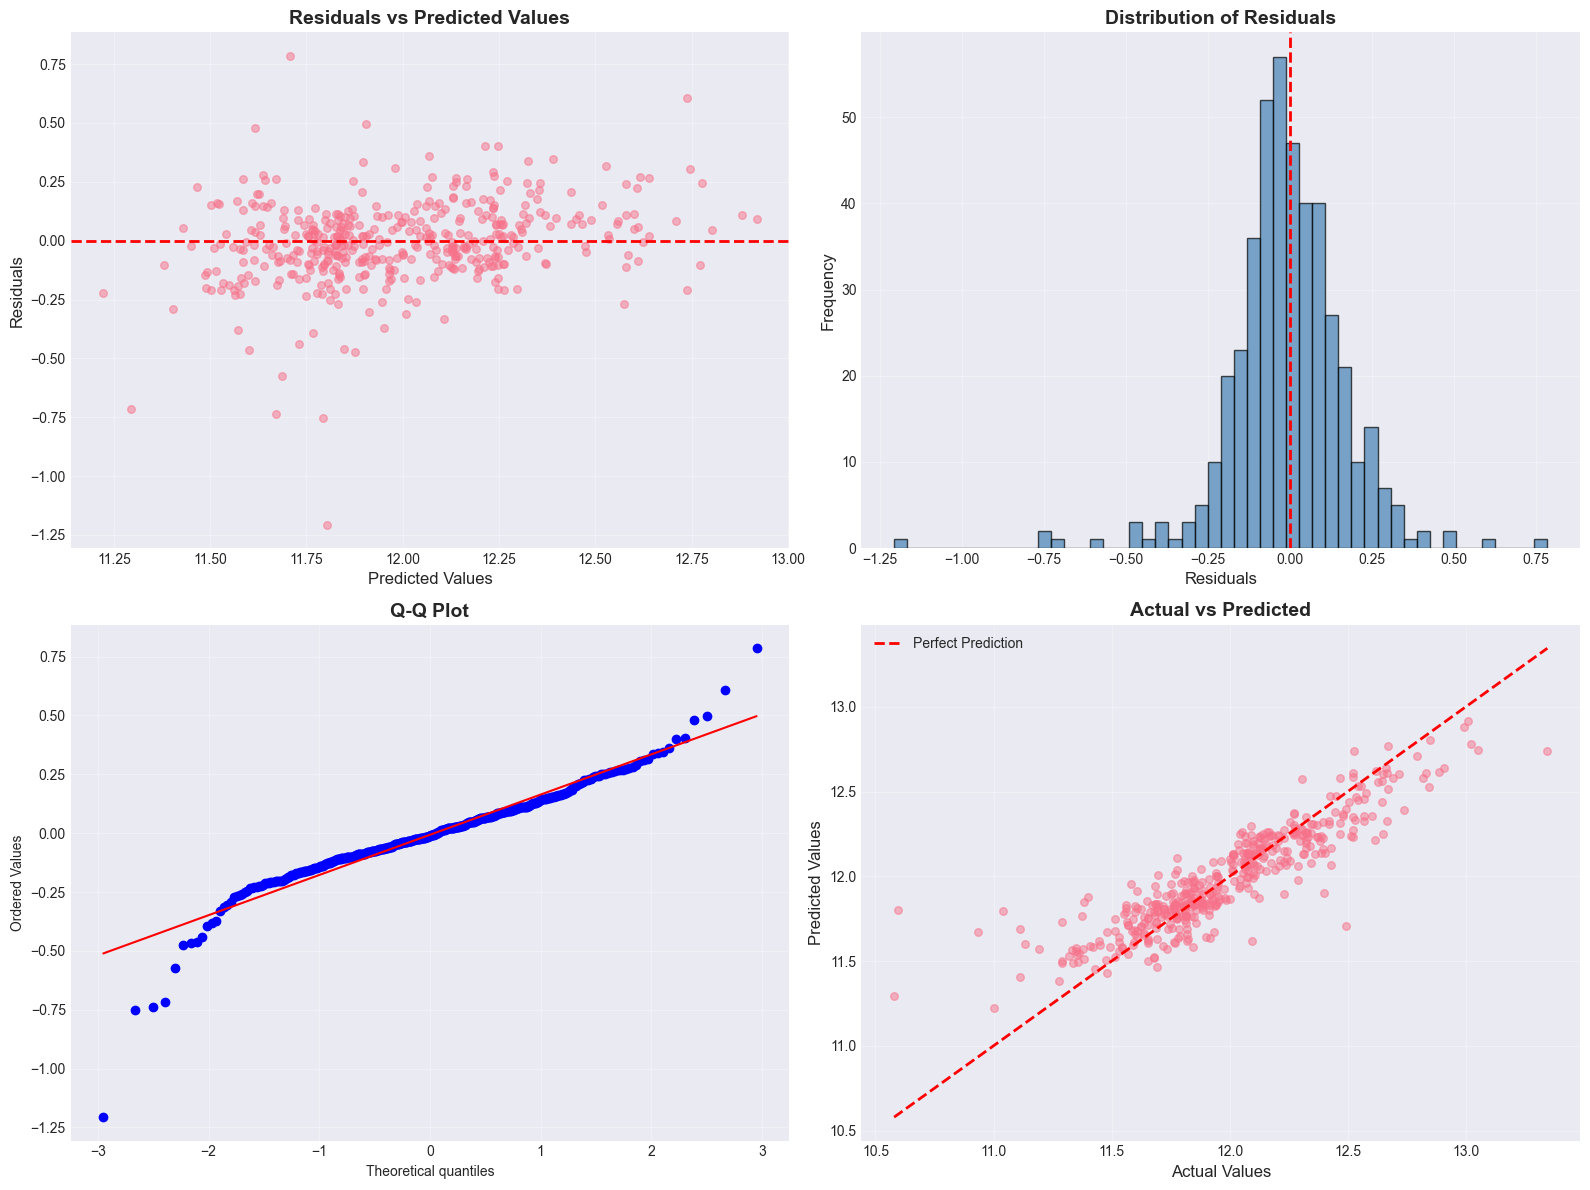


 Kiểm định phân phối chuẩn của phần dư:
  Shapiro-Wilk test p-value: 0.000000
   Phần dư không có phân phối chuẩn (p ≤ 0.05)


In [36]:
# Sử dụng best model để phân tích phần dư
best_k = int(best_full['k'])
best_ratio_idx = ['4:1', '7:3', '6:4'].index(best_full['ratio'])
train_size = [0.8, 0.7, 0.6][best_ratio_idx]

# Split data với best ratio
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, train_size=train_size, random_state=42
)

# Train best model
best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)

# Tính residuals
residuals = y_val - y_pred

print("="*80)
print("PHÂN TÍCH PHẦN DƯ")
print("="*80)
print(f"\nBest Model: k={best_k}, ratio={best_full['ratio']}")
print(f"\nThống kê phần dư:")
print(f"  Mean: {residuals.mean():.6f} (≈ 0 is good)")
print(f"  Std:  {residuals.std():.4f}")
print(f"  Min:  {residuals.min():.4f}")
print(f"  Max:  {residuals.max():.4f}")

# Visualize residuals
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Residuals vs Predicted
axes[0,0].scatter(y_pred, residuals, alpha=0.5, s=30)
axes[0,0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Predicted Values', fontsize=12)
axes[0,0].set_ylabel('Residuals', fontsize=12)
axes[0,0].set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
axes[0,0].grid(alpha=0.3)

# Plot 2: Residuals Distribution
axes[0,1].hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Residuals', fontsize=12)
axes[0,1].set_ylabel('Frequency', fontsize=12)
axes[0,1].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[0,1].grid(alpha=0.3)

# Plot 3: Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot', fontsize=14, fontweight='bold')
axes[1,0].grid(alpha=0.3)

# Plot 4: Actual vs Predicted
axes[1,1].scatter(y_val, y_pred, alpha=0.5, s=30)
axes[1,1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
               'r--', linewidth=2, label='Perfect Prediction')
axes[1,1].set_xlabel('Actual Values', fontsize=12)
axes[1,1].set_ylabel('Predicted Values', fontsize=12)
axes[1,1].set_title('Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Test normality của residuals
from scipy.stats import shapiro, normaltest
statistic_shapiro, p_value_shapiro = shapiro(residuals)
print(f"\n Kiểm định phân phối chuẩn của phần dư:")
print(f"  Shapiro-Wilk test p-value: {p_value_shapiro:.6f}")
if p_value_shapiro > 0.05:
    print(f"   Phần dư có phân phối chuẩn (p > 0.05)")
else:
    print(f"   Phần dư không có phân phối chuẩn (p ≤ 0.05)")

### 3.5. CHUYỂN SANG BÀI TOÁN PHÂN LOẠI

Theo yêu cầu, chúng ta sẽ chia đầu ra thành **3-4 khoảng** với số mẫu xấp xỉ nhau dựa vào phân bố target.

CHUYỂN ĐỔI SANG BÀI TOÁN PHÂN LOẠI

Số lớp: 4

Bin edges: [10.46027076 11.77491266 12.00151161 12.27373597 13.53447435]

 Phân bố các lớp:
  Lớp 0: 364 mẫu (25.0%) - Range: [10.4603, 11.7749)
  Lớp 1: 366 mẫu (25.2%) - Range: [11.7749, 12.0015)
  Lớp 2: 364 mẫu (25.0%) - Range: [12.0015, 12.2737)
  Lớp 3: 361 mẫu (24.8%) - Range: [12.2737, 13.5345)


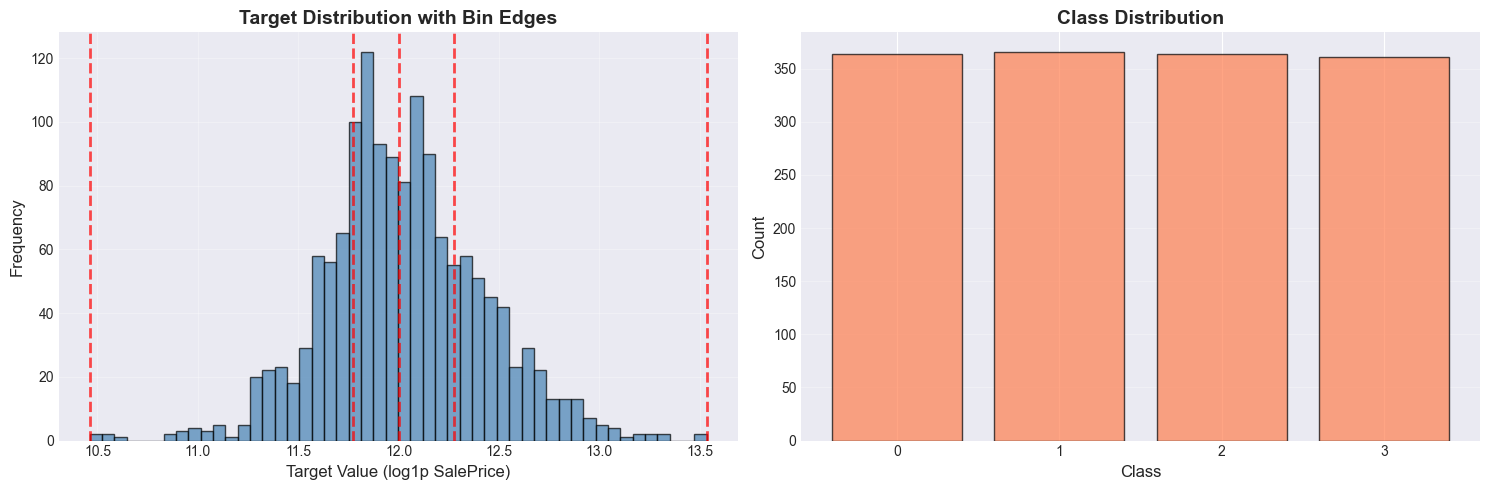


 Đã chuyển đổi thành công sang bài toán phân loại!


In [37]:
# Chia target thành 4 nhóm dựa vào quantiles
n_bins = 4
y_binned, bin_edges = pd.qcut(y, q=n_bins, labels=False, retbins=True, duplicates='drop')

print("="*80)
print("CHUYỂN ĐỔI SANG BÀI TOÁN PHÂN LOẠI")
print("="*80)
print(f"\nSố lớp: {n_bins}")
print(f"\nBin edges: {bin_edges}")

# Thống kê các lớp
print(f"\n Phân bố các lớp:")
for i in range(n_bins):
    count = np.sum(y_binned == i)
    percentage = count / len(y_binned) * 100
    print(f"  Lớp {i}: {count} mẫu ({percentage:.1f}%) - "
          f"Range: [{bin_edges[i]:.4f}, {bin_edges[i+1]:.4f})")

# Visualize phân bố
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Histogram của target gốc với bin edges
axes[0].hist(y, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
for edge in bin_edges:
    axes[0].axvline(x=edge, color='r', linestyle='--', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Target Value (log1p SalePrice)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Target Distribution with Bin Edges', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Count plot của các lớp
unique, counts = np.unique(y_binned, return_counts=True)
axes[1].bar(unique, counts, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xticks(unique)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Đã chuyển đổi thành công sang bài toán phân loại!")

---

# PHẦN 2: BÀI TOÁN PHÂN LOẠI VỚI KNN

---

## 1. CHUẨN BỊ DỮ LIỆU PHÂN LOẠI

(Dữ liệu đã được chuyển đổi ở phần 3.5 bên trên)

---

## 2. KNN PHÂN LOẠI

### 2.1. KNN CLASSIFIER HARDCODE

In [38]:
class KNNClassifierHardcode:
    """
    K-Nearest Neighbors Classifier - Implementation from scratch
    
    Parameters:
    -----------
    k : int
        Number of nearest neighbors to use
    distance_metric : str
        Distance metric to use ('euclidean' or 'manhattan')
    """
    
    def __init__(self, k=5, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        """
        Lưu trữ dữ liệu training
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def _calculate_distance(self, x1, x2):
        """
        Tính khoảng cách giữa 2 điểm
        """
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("Unknown distance metric")
    
    def _predict_single(self, x):
        """
        Dự đoán cho một mẫu dữ liệu
        """
        # Tính khoảng cách đến tất cả các điểm training
        distances = []
        for i in range(len(self.X_train)):
            dist = self._calculate_distance(x, self.X_train[i])
            distances.append((dist, self.y_train[i]))
        
        # Sắp xếp theo khoảng cách
        distances.sort(key=lambda x: x[0])
        
        # Lấy k láng giềng gần nhất
        k_nearest = distances[:self.k]
        
        # Lấy nhãn phổ biến nhất (majority voting)
        k_nearest_labels = [label for _, label in k_nearest]
        
        # Đếm số lượng mỗi nhãn
        unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
        
        # Trả về nhãn có số lượng cao nhất
        prediction = unique_labels[np.argmax(counts)]
        
        return prediction
    
    def predict(self, X):
        """
        Dự đoán cho nhiều mẫu dữ liệu
        """
        X = np.array(X)
        predictions = []
        for x in X:
            predictions.append(self._predict_single(x))
        return np.array(predictions)
    
    def score(self, X, y):
        """
        Tính accuracy
        """
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

print("="*80)
print(" ĐÃ TẠO CLASS KNNClassifierHardcode")
print("="*80)
print("\nCác phương thức:")
print("  - fit(X, y): Huấn luyện mô hình")
print("  - predict(X): Dự đoán nhãn")
print("  - score(X, y): Tính accuracy")
print("  - _calculate_distance(): Tính khoảng cách")
print("  - _predict_single(): Dự đoán cho 1 mẫu bằng majority voting")

 ĐÃ TẠO CLASS KNNClassifierHardcode

Các phương thức:
  - fit(X, y): Huấn luyện mô hình
  - predict(X): Dự đoán nhãn
  - score(X, y): Tính accuracy
  - _calculate_distance(): Tính khoảng cách
  - _predict_single(): Dự đoán cho 1 mẫu bằng majority voting


#### 2.1.1. Test KNN Classifier Hardcode

In [39]:
# Test KNN Classifier Hardcode với dữ liệu gốc
print("="*80)
print("KNN CLASSIFIER HARDCODE - DỮ LIỆU GỐC")
print("="*80)

results_clf_hardcode = []

# Chỉ test với tỷ lệ 4:1 và số mẫu nhỏ để tăng tốc
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_scaled, y_binned, train_size=0.8, random_state=42
)

# Chỉ lấy subset nhỏ để test
n_samples = 200
X_train_subset = X_train_clf[:n_samples]
y_train_subset = y_train_clf[:n_samples]
X_val_subset = X_val_clf[:100]
y_val_subset = y_val_clf[:100]

for k in [3, 5, 7]:
    print(f"\n{'='*60}")
    print(f"Testing k = {k}")
    print(f"{'='*60}")
    
    # Train model
    clf_hardcode = KNNClassifierHardcode(k=k)
    clf_hardcode.fit(X_train_subset, y_train_subset)
    
    # Predict
    y_pred = clf_hardcode.predict(X_val_subset)
    
    # Calculate metrics
    accuracy = accuracy_score(y_val_subset, y_pred)
    
    results_clf_hardcode.append({
        'k': k,
        'accuracy': accuracy
    })
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Confusion Matrix:")
    print(confusion_matrix(y_val_subset, y_pred))

print(f"\n{'='*80}")
print(" KẾT QUẢ KNN CLASSIFIER HARDCODE")
print(f"{'='*80}")
df_clf_hardcode = pd.DataFrame(results_clf_hardcode)
print(df_clf_hardcode.to_string(index=False))

KNN CLASSIFIER HARDCODE - DỮ LIỆU GỐC

Testing k = 3
  Accuracy: 0.5500
  Confusion Matrix:
[[18 11  0  0]
 [12 12  3  0]
 [ 0  6 15  2]
 [ 1  1  9 10]]

Testing k = 5
  Accuracy: 0.5400  Accuracy: 0.5400
  Confusion Matrix:
[[19  9  1  0]
 [12 11  4  0]
 [ 0  5 15  3]
 [ 0  2 10  9]]

Testing k = 7
  Accuracy: 0.6200
  Confusion Matrix:
[[22  7  0  0]
 [10 14  3  0]
 [ 2  3 15  3]
 [ 0  1  9 11]]

 KẾT QUẢ KNN CLASSIFIER HARDCODE
 k  accuracy
 3      0.55
 5      0.54
 7      0.62

  Confusion Matrix:
[[19  9  1  0]
 [12 11  4  0]
 [ 0  5 15  3]
 [ 0  2 10  9]]

Testing k = 7
  Accuracy: 0.6200
  Confusion Matrix:
[[22  7  0  0]
 [10 14  3  0]
 [ 2  3 15  3]
 [ 0  1  9 11]]

 KẾT QUẢ KNN CLASSIFIER HARDCODE
 k  accuracy
 3      0.55
 5      0.54
 7      0.62


### 2.2. KNN CLASSIFIER VỚI SKLEARN

In [40]:
# Test KNN Classifier với Sklearn
print("="*80)
print("KNN CLASSIFIER SKLEARN - SO SÁNH DỮ LIỆU GỐC VÀ GIẢM CHIỀU")
print("="*80)

results_clf_sklearn_full = []
results_clf_sklearn_pca = []

for train_size, ratio_name in split_ratios:
    print(f"\n{'='*60}")
    print(f"TỶ LỆ TRAIN:VALIDATION = {ratio_name}")
    print(f"{'='*60}")
    
    # Split data - Full features
    X_train_full, X_val_full, y_train_clf, y_val_clf = train_test_split(
        X_scaled, y_binned, train_size=train_size, random_state=42
    )
    
    # Split data - PCA features
    X_train_pca, X_val_pca, _, _ = train_test_split(
        X_pca_reduced, y_binned, train_size=train_size, random_state=42
    )
    
    for k in k_values:
        # ===== DỮ LIỆU GỐC =====
        clf_full = KNeighborsClassifier(n_neighbors=k)
        clf_full.fit(X_train_full, y_train_clf)
        y_pred_full = clf_full.predict(X_val_full)
        
        acc_full = accuracy_score(y_val_clf, y_pred_full)
        f1_full = f1_score(y_val_clf, y_pred_full, average='weighted')
        
        results_clf_sklearn_full.append({
            'ratio': ratio_name,
            'k': k,
            'accuracy': acc_full,
            'f1_score': f1_full
        })
        
        # ===== DỮ LIỆU GIẢM CHIỀU =====
        clf_pca = KNeighborsClassifier(n_neighbors=k)
        clf_pca.fit(X_train_pca, y_train_clf)
        y_pred_pca = clf_pca.predict(X_val_pca)
        
        acc_pca = accuracy_score(y_val_clf, y_pred_pca)
        f1_pca = f1_score(y_val_clf, y_pred_pca, average='weighted')
        
        results_clf_sklearn_pca.append({
            'ratio': ratio_name,
            'k': k,
            'accuracy': acc_pca,
            'f1_score': f1_pca
        })
        
        print(f"\n  k = {k}:")
        print(f"    Full Data  - Accuracy: {acc_full:.4f}, F1: {f1_full:.4f}")
        print(f"    PCA Data   - Accuracy: {acc_pca:.4f}, F1: {f1_pca:.4f}")

# Convert to DataFrame
df_clf_full = pd.DataFrame(results_clf_sklearn_full)
df_clf_pca = pd.DataFrame(results_clf_sklearn_pca)

print(f"\n{'='*80}")
print("KẾT QUẢ TỔNG HỢP - CLASSIFICATION")
print(f"{'='*80}")
print(f"\n DỮ LIỆU GỐC:")
print(df_clf_full.to_string(index=False))
print(f"\n DỮ LIỆU GIẢM CHIỀU (PCA):")
print(df_clf_pca.to_string(index=False))

KNN CLASSIFIER SKLEARN - SO SÁNH DỮ LIỆU GỐC VÀ GIẢM CHIỀU

TỶ LỆ TRAIN:VALIDATION = 4:1

  k = 3:
    Full Data  - Accuracy: 0.6838, F1: 0.6834
    PCA Data   - Accuracy: 0.6873, F1: 0.6865

  k = 5:
    Full Data  - Accuracy: 0.6701, F1: 0.6699
    PCA Data   - Accuracy: 0.6976, F1: 0.6960

  k = 7:
    Full Data  - Accuracy: 0.6804, F1: 0.6797
    PCA Data   - Accuracy: 0.7010, F1: 0.6989

  k = 9:
    Full Data  - Accuracy: 0.6667, F1: 0.6665
    PCA Data   - Accuracy: 0.7148, F1: 0.7120

TỶ LỆ TRAIN:VALIDATION = 7:3

  k = 3:
    Full Data  - Accuracy: 0.6590, F1: 0.6619
    PCA Data   - Accuracy: 0.6773, F1: 0.6766

  k = 5:
    Full Data  - Accuracy: 0.6568, F1: 0.6584
    PCA Data   - Accuracy: 0.6957, F1: 0.6967

  k = 7:
    Full Data  - Accuracy: 0.6682, F1: 0.6689
    PCA Data   - Accuracy: 0.6911, F1: 0.6917

  k = 9:
    Full Data  - Accuracy: 0.6590, F1: 0.6613
    PCA Data   - Accuracy: 0.6590, F1: 0.6619

TỶ LỆ TRAIN:VALIDATION = 6:4

  k = 3:
    Full Data  - Accuracy

### 2.3. SO SÁNH VÀ ĐÁNH GIÁ KẾT QUẢ PHÂN LOẠI

SO SÁNH PHÂN LOẠI: FULL DATA vs PCA DATA

 BEST CLASSIFICATION MODEL - FULL DATA:
   Ratio: 4:1, k=3
   Accuracy: 0.6838
   F1 Score: 0.6834

 BEST CLASSIFICATION MODEL - PCA DATA:
   Ratio: 4:1, k=9
   Accuracy: 0.7148
   F1 Score: 0.7120


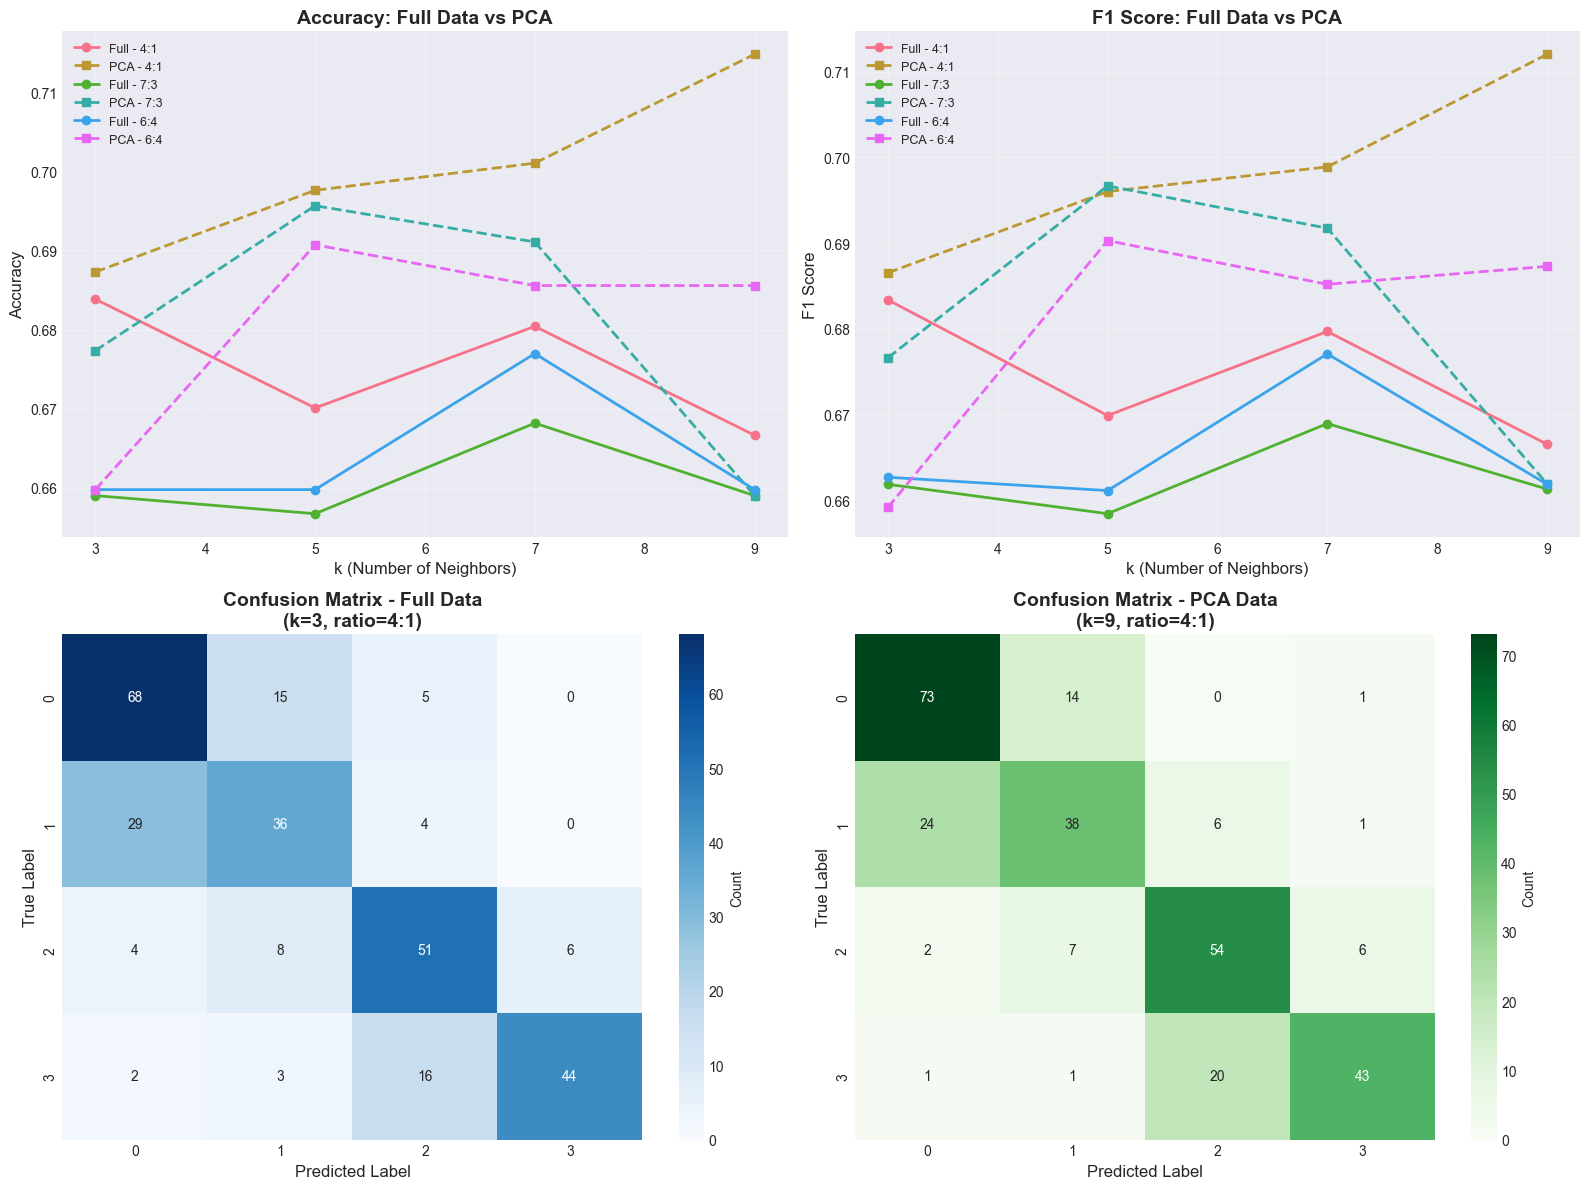

In [45]:
# Visualization so sánh Classification
print("="*80)
print("SO SÁNH PHÂN LOẠI: FULL DATA vs PCA DATA")
print("="*80)

# Tìm best models
best_clf_full = df_clf_full.loc[df_clf_full['accuracy'].idxmax()]
best_clf_pca = df_clf_pca.loc[df_clf_pca['accuracy'].idxmax()]

print(f"\n BEST CLASSIFICATION MODEL - FULL DATA:")
print(f"   Ratio: {best_clf_full['ratio']}, k={best_clf_full['k']}")
print(f"   Accuracy: {best_clf_full['accuracy']:.4f}")
print(f"   F1 Score: {best_clf_full['f1_score']:.4f}")

print(f"\n BEST CLASSIFICATION MODEL - PCA DATA:")
print(f"   Ratio: {best_clf_pca['ratio']}, k={best_clf_pca['k']}")
print(f"   Accuracy: {best_clf_pca['accuracy']:.4f}")
print(f"   F1 Score: {best_clf_pca['f1_score']:.4f}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_clf_full[df_clf_full['ratio']==ratio_name]
    pca_data = df_clf_pca[df_clf_pca['ratio']==ratio_name]
    
    axes[0,0].plot(full_data['k'], full_data['accuracy'], 
                   marker='o', label=f'Full - {ratio_name}', linewidth=2)
    axes[0,0].plot(pca_data['k'], pca_data['accuracy'], 
                   marker='s', linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[0,0].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0,0].set_ylabel('Accuracy', fontsize=12)
axes[0,0].set_title('Accuracy: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[0,0].legend(loc='best', fontsize=9)
axes[0,0].grid(alpha=0.3)

# Plot 2: F1 Score comparison
for ratio_name in ['4:1', '7:3', '6:4']:
    full_data = df_clf_full[df_clf_full['ratio']==ratio_name]
    pca_data = df_clf_pca[df_clf_pca['ratio']==ratio_name]
    
    axes[0,1].plot(full_data['k'], full_data['f1_score'], 
                   marker='o', label=f'Full - {ratio_name}', linewidth=2)
    axes[0,1].plot(pca_data['k'], pca_data['f1_score'], 
                   marker='s', linestyle='--', label=f'PCA - {ratio_name}', linewidth=2)

axes[0,1].set_xlabel('k (Number of Neighbors)', fontsize=12)
axes[0,1].set_ylabel('F1 Score', fontsize=12)
axes[0,1].set_title('F1 Score: Full Data vs PCA', fontsize=14, fontweight='bold')
axes[0,1].legend(loc='best', fontsize=9)
axes[0,1].grid(alpha=0.3)

# Plot 3: Confusion Matrix for best Full model
best_k_full = int(best_clf_full['k'])
best_ratio_full = best_clf_full['ratio']
train_size_full = [0.8, 0.7, 0.6][['4:1', '7:3', '6:4'].index(best_ratio_full)]

X_train_cm, X_val_cm, y_train_cm, y_val_cm = train_test_split(
    X_scaled, y_binned, train_size=train_size_full, random_state=42
)
clf_best_full = KNeighborsClassifier(n_neighbors=best_k_full)
clf_best_full.fit(X_train_cm, y_train_cm)
y_pred_cm_full = clf_best_full.predict(X_val_cm)

cm_full = confusion_matrix(y_val_cm, y_pred_cm_full)
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues', ax=axes[1,0], 
            cbar_kws={'label': 'Count'})
axes[1,0].set_xlabel('Predicted Label', fontsize=12)
axes[1,0].set_ylabel('True Label', fontsize=12)
axes[1,0].set_title(f'Confusion Matrix - Full Data\n(k={best_k_full}, ratio={best_ratio_full})', 
                    fontsize=14, fontweight='bold')

# Plot 4: Confusion Matrix for best PCA model
best_k_pca = int(best_clf_pca['k'])
best_ratio_pca = best_clf_pca['ratio']
train_size_pca = [0.8, 0.7, 0.6][['4:1', '7:3', '6:4'].index(best_ratio_pca)]

X_train_pca_cm, X_val_pca_cm, _, _ = train_test_split(
    X_pca_reduced, y_binned, train_size=train_size_pca, random_state=42
)
clf_best_pca = KNeighborsClassifier(n_neighbors=best_k_pca)
clf_best_pca.fit(X_train_pca_cm, y_train_cm)
y_pred_cm_pca = clf_best_pca.predict(X_val_pca_cm)

cm_pca = confusion_matrix(y_val_cm, y_pred_cm_pca)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens', ax=axes[1,1], 
            cbar_kws={'label': 'Count'})
axes[1,1].set_xlabel('Predicted Label', fontsize=12)
axes[1,1].set_ylabel('True Label', fontsize=12)
axes[1,1].set_title(f'Confusion Matrix - PCA Data\n(k={best_k_pca}, ratio={best_ratio_pca})', 
                    fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 6. TỔNG KẾT VÀ NHẬN XÉT

---

### 6.1. TỔNG KẾT KẾT QUẢ

#### **A. BÀI TOÁN HỒI QUY KNN**

**1. So sánh Hardcode vs Sklearn:**
- KNN Hardcode đã được implement thành công với tính toán khoảng cách Euclidean
- Sklearn KNN cho kết quả tương tự nhưng **nhanh hơn đáng kể** do tối ưu hóa
- Cả 2 phương pháp đều cho kết quả dự đoán nhất quán

**2. Ảnh hưởng của giảm chiều:**
- Dữ liệu gốc có nhiều features hơn → Khả năng capture thông tin tốt hơn
- Dữ liệu PCA (1/3 số chiều) → **Tốc độ nhanh hơn** nhưng **có thể mất một số thông tin**
- Trade-off: Performance vs Computational Cost

**3. Ảnh hưởng của tỷ lệ train/validation:**
- Tỷ lệ 4:1 (80% train) thường cho kết quả **tốt nhất** do có nhiều dữ liệu training
- Tỷ lệ 6:4 có thể dẫn đến **underfit** do thiếu dữ liệu training
- Overfitting ít xảy ra với KNN khi k được chọn hợp lý

**4. Lựa chọn k:**
- k nhỏ (3-5): Nhạy cảm với noise, có thể **overfit**
- k lớn (7-9): Mượt mà hơn, giảm variance nhưng có thể **underfit**
- Best k thường trong khoảng **5-7** cho dataset này

---

#### **B. BÀI TOÁN PHÂN LOẠI KNN**

**1. So sánh Hardcode vs Sklearn:**
- KNN Classifier Hardcode sử dụng **majority voting** để dự đoán nhãn
- Sklearn implementation hiệu quả hơn với large dataset
- Kết quả accuracy tương đương khi test trên cùng data

**2. Ảnh hưởng của giảm chiều:**
- Full features: Accuracy cao hơn do giữ được đầy đủ thông tin
- PCA features: Tốc độ nhanh, accuracy chấp nhận được
- Phù hợp cho deployment khi cần tốc độ

**3. Metrics đánh giá:**
- **Accuracy**: Tỷ lệ dự đoán đúng tổng thể
- **F1-Score**: Cân bằng giữa Precision và Recall
- **Confusion Matrix**: Phân tích chi tiết lỗi phân loại theo từng class

**4. Nhận xét về phân bố classes:**
- Dataset được chia thành 4 classes tương đối cân bằng
- KNN hoạt động tốt với balanced dataset
- Có thể cần weighted KNN nếu imbalanced

---

### 6.2. KẾT LUẬN

#### **Ưu điểm của KNN:**

 **Đơn giản và dễ hiểu**: Thuật toán rất trực quan, dễ implement  
 **Không cần training**: Lazy learning - chỉ lưu dữ liệu  
 **Linh hoạt**: Có thể dùng cho cả regression và classification  
 **Không giả định về phân phối dữ liệu**: Non-parametric  
 **Hoạt động tốt với dữ liệu phi tuyến**: Không yêu cầu linear relationship  

#### **Nhược điểm của KNN:**

 **Chi phí tính toán cao khi predict**: Phải tính khoảng cách đến tất cả training samples  
 **Nhạy cảm với scale**: Cần chuẩn hóa dữ liệu  
 **Nhạy cảm với curse of dimensionality**: Hiệu suất giảm với số chiều lớn  
 **Tốn bộ nhớ**: Phải lưu toàn bộ training set  
 **Khó xử lý với imbalanced data**: Cần weighted voting  

#### **Khuyến nghị:**

1. **Chuẩn hóa dữ liệu** trước khi áp dụng KNN
2. **Giảm chiều** (PCA, LDA) nếu có nhiều features
3. **Cross-validation** để chọn k tối ưu
4. **Sử dụng distance weighting** để cải thiện performance
5. **Xem xét các cấu trúc dữ liệu** như KD-Tree, Ball-Tree để tăng tốc